In [1]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

In [2]:
taco_dense = pd.read_csv("./results/taco_dense_mem.csv")
taco_sparse = pd.read_csv("./results/taco_csr_opt_mem.csv")
bitmap = pd.read_csv("./results/bitmap_mem.csv")

In [3]:
def format_mem(df, name: str):
    df["kernel"] = name
    df['sparsity'] = df['file'].str.split('_').str[-1].str.split('.').str[0].astype(int)
    df['sparsity'] = 100 - df['sparsity']
    df['mb'] = df['bytes'] / 1024 / 1024
    return df

In [4]:
data_frames = [
    format_mem(taco_dense, "dense"),
    format_mem(taco_sparse, "human_expert"),
    format_mem(bitmap, "bitmap"),
]

In [5]:
full_df = pd.concat(data_frames)
full_df = full_df.sort_values(by=['M', 'sparsity'])
full_df = full_df.groupby(['kernel', 'sparsity', 'M'], as_index=False)['mb'].mean()
full_df = full_df[full_df["M"] == 1024]

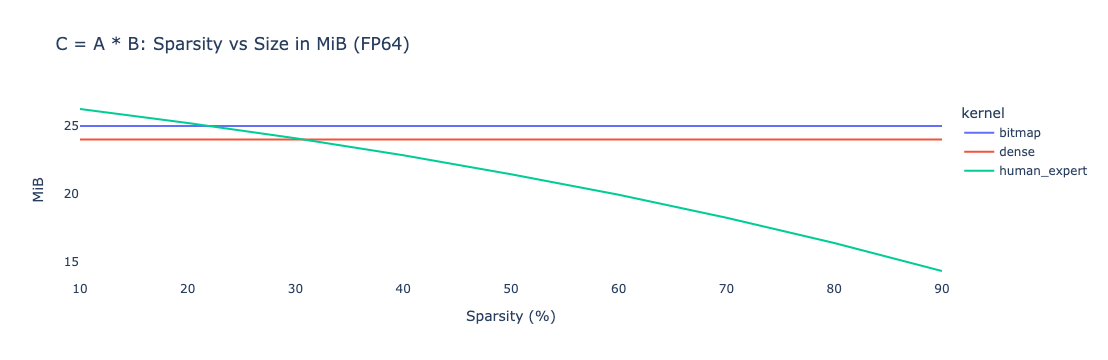

In [6]:
fig = px.line(full_df, 
              x='sparsity', 
              y='mb', 
              color='kernel',
              title='C = A * B: Sparsity vs Size in MiB (FP64)',
              labels={'sparsity': 'Sparsity (%)', 'mb': 'MiB'})
fig.update_layout(plot_bgcolor='white')
fig.show()